# Patient Similarity Analysis: Multimodal Relatives vs HANCATHON
Analyze how multimodal relative patients and HANCATHON cohort relate to the Hancock training data.

In [12]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import sys

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

sys.path.append(str(Path().resolve().parent))
from app.patient_encoding import load_and_encode_patient
from data_exploration.umap_embedding import get_umap_embedding

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Training Data & Models

In [13]:
# Load training data
features_dir = "../features"
df_train = get_umap_embedding(features_dir, umap_min_dist=0.1, umap_n_neighbors=15)

# Load models
preprocessor = joblib.load("../models/preprocessor.pkl")
with open("../models/feature_order.json") as f:
    feature_order = json.load(f)

# Encode training data
X_train = df_train[feature_order].copy()
X_train_encoded = preprocessor.transform(X_train)

print(f"✓ Loaded {len(df_train)} training patients")
print(f"✓ Total features: {len(feature_order)}")

✓ Loaded 626 training patients
✓ Total features: 79


## 2. Multimodal Relative Similarity

In [14]:
# Load new patients from data directory
patient_ids = ['801', '804', '805', '807', '809', '810', '812', '814']
new_patients = {}

print("Loading multimodal relative patients...\n")
for patient_id in patient_ids:
    patient_path = f"../data/{patient_id}/raw"
    try:
        df_patient = load_and_encode_patient(patient_path, patient_id=patient_id)
        new_patients[patient_id] = df_patient
        print(f"✓ Loaded patient {patient_id}")
    except Exception as e:
        print(f"✗ Failed to load patient {patient_id}: {e}")

print(f"\n✓ Successfully loaded {len(new_patients)} multimodal relative patients")

Loading multimodal relative patients...

['icd_codes_801.txt']
  patient_id   icd_code
0        801  R048 C320
  year_of_initial_diagnosis age_at_initial_diagnosis   sex smoking_status  \
0                      None                       80  male         former   

  primarily_metastasis survival_status survival_status_with_cause  \
0                  yes            None                       None   

  days_to_last_information first_treatment_intent first_treatment_modality  \
0                     None                   None                     None   

   ... adjuvant_radiotherapy adjuvant_radiotherapy_modality  \
0  ...                  None                           None   

  adjuvant_systemic_therapy adjuvant_systemic_therapy_modality  \
0                      None                               None   

  adjuvant_radiochemotherapy recurrence days_to_recurrence  \
0                       None       None               None   

  days_to_metastasis_1 days_to_progress_1 patient_id 

In [15]:
# Compute similarity of each new patient to all training patients
results = []
all_similarities = {}

print("Computing similarities...\n")
print("="*90)

for patient_id, df_patient in new_patients.items():
    # Encode new patient
    X_patient = df_patient[feature_order].copy()
    X_patient_encoded = preprocessor.transform(X_patient)
    
    # Compute similarity to all training patients
    similarities = cosine_similarity(X_patient_encoded, X_train_encoded)[0]
    all_similarities[patient_id] = similarities
    
    # Get top 5 similar training patients
    top_idx = similarities.argsort()[::-1][:5]
    top_ids = [df_train.iloc[i]['patient_id'] for i in top_idx]
    top_scores = similarities[top_idx]
    
    # Statistics
    mean_sim = np.mean(similarities)
    max_sim = np.max(similarities)
    min_sim = np.min(similarities)
    
    print(f"\nPatient {patient_id}:")
    print(f"  Top 5 similar:  {' → '.join(str(int(id)) for id in top_ids)}")
    print(f"  Scores:         {[f'{s:.4f}' for s in top_scores]}")
    print(f"  Cohort stats:   Mean={mean_sim:.4f}, Max={max_sim:.4f}, Min={min_sim:.4f}")
    
    results.append({
        'Patient': patient_id,
        'Most_Similar': int(top_ids[0]),
        'Top5_Avg_Score': top_scores.mean(),
        'Cohort_Mean': mean_sim,
        'Cohort_Max': max_sim,
        'Cohort_Min': min_sim
    })

print("\n" + "="*90)
results_df = pd.DataFrame(results)
print("\nSUMMARY TABLE:")
print(results_df.to_string(index=False))

Computing similarities...


Patient 801:
  Top 5 similar:  709 → 192 → 186 → 674 → 9
  Scores:         ['0.6514', '0.6481', '0.6456', '0.6180', '0.6131']
  Cohort stats:   Mean=0.1151, Max=0.6514, Min=-0.3644

Patient 804:
  Top 5 similar:  202 → 480 → 41 → 719 → 242
  Scores:         ['0.6810', '0.6783', '0.6719', '0.6419', '0.6342']
  Cohort stats:   Mean=0.1668, Max=0.6810, Min=-0.3476

Patient 805:
  Top 5 similar:  573 → 284 → 724 → 167 → 7
  Scores:         ['0.6716', '0.6507', '0.6293', '0.5905', '0.5842']
  Cohort stats:   Mean=0.0830, Max=0.6716, Min=-0.3728

Patient 807:
  Top 5 similar:  270 → 684 → 416 → 220 → 113
  Scores:         ['0.6258', '0.5800', '0.5791', '0.5786', '0.5777']
  Cohort stats:   Mean=0.1022, Max=0.6258, Min=-0.3800

Patient 809:
  Top 5 similar:  318 → 669 → 750 → 145 → 202
  Scores:         ['0.6107', '0.5950', '0.5704', '0.5612', '0.5604']
  Cohort stats:   Mean=0.1408, Max=0.6107, Min=-0.3979

Patient 810:
  Top 5 similar:  723 → 481 → 663 → 587 → 87

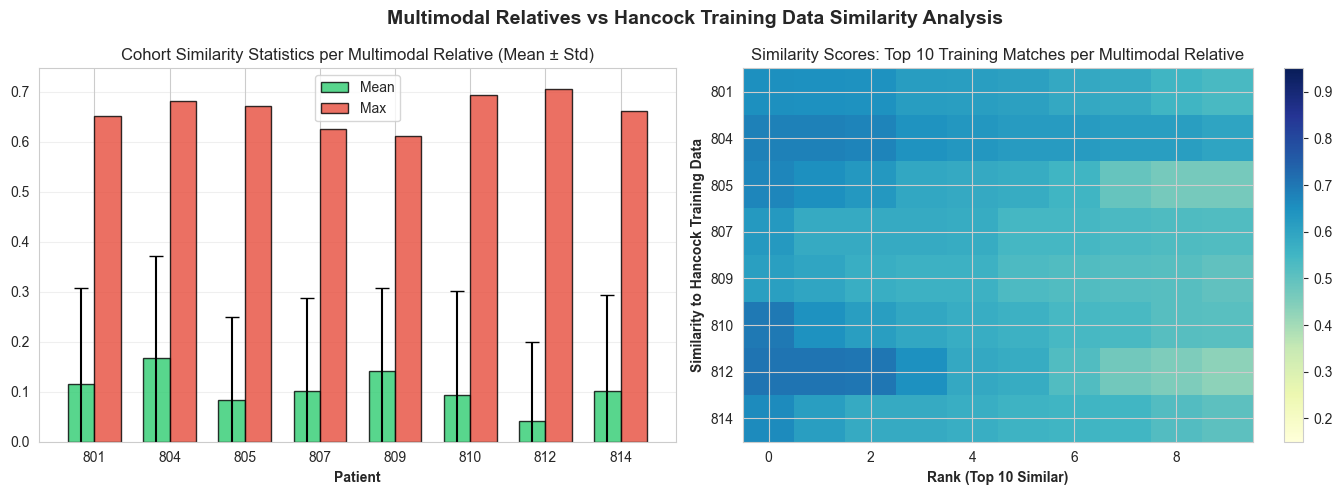

✓ Visualizations complete


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Multimodal Relatives vs Hancock Training Data Similarity Analysis', fontsize=14, fontweight='bold')
patient_ids_list = list(all_similarities.keys())
# Plot 1: Mean and max similarities per patient with std error bars
ax1 = axes[0]
ax2 = axes[1]
x = np.arange(len(results_df))
width = 0.35

# Calculate std for error bars
std_per_patient = [np.std(all_similarities[pid]) for pid in patient_ids_list]

ax1.bar(x - width/2, results_df['Cohort_Mean'], width, label='Mean', color='#2ecc71', 
        edgecolor='black', yerr=[std_per_patient, std_per_patient], capsize=5, alpha=0.8)
ax1.bar(x + width/2, results_df['Cohort_Max'], width, label='Max', color='#e74c3c', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Patient', fontweight='bold')
ax2.set_ylabel('Similarity to Hancock Training Data', fontweight='bold')
ax1.set_ylim(0,)
ax1.set_title('Cohort Similarity Statistics per Multimodal Relative (Mean ± Std)')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Patient'])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Heatmap of top similarities
ax2 = axes[1]
heatmap_data = []
for pid in patient_ids_list:
    similarities = all_similarities[pid]
    # Show top 10
    top_10_idx = similarities.argsort()[::-1][:10]
    heatmap_data.append(similarities[top_10_idx])

heatmap_array = np.array(heatmap_data)
im = ax2.imshow(heatmap_array, cmap='YlGnBu', aspect='auto', vmin=0.15, vmax=0.95)
ax2.set_yticks(range(len(patient_ids_list)))
ax2.set_yticklabels(patient_ids_list)
ax2.set_xlabel('Rank (Top 10 Similar)', fontweight='bold')
ax2.set_title('Similarity Scores: Top 10 Training Matches per Multimodal Relative')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

In [17]:
# Calculate mean ± std from maximum similarities across all patients
max_similarities = results_df['Cohort_Max'].values
mean_max_sim = np.mean(max_similarities)
std_max_sim = np.std(max_similarities)

print("\n" + "="*60)
print("MAXIMUM SIMILARITIES ACROSS ALL MULTIMODAL RELATIVES")
print("="*60)
print(f"Mean ± Std:                   {mean_max_sim:.4f} ± {std_max_sim:.4f}")
print("="*60)


MAXIMUM SIMILARITIES ACROSS ALL MULTIMODAL RELATIVES
Mean ± Std:                   0.6627 ± 0.0306


## 3. HANCATHON Cohort Similarity (765–798)

Loading HANCATHON patients (765-798)...

['icd_codes_765.txt']
  patient_id icd_code
0        765         
  year_of_initial_diagnosis age_at_initial_diagnosis   sex smoking_status  \
0                      None                       80  male         former   

  primarily_metastasis survival_status survival_status_with_cause  \
0                   no            None                       None   

  days_to_last_information first_treatment_intent first_treatment_modality  \
0                     None                   None                     None   

   ... adjuvant_radiotherapy adjuvant_radiotherapy_modality  \
0  ...                  None                           None   

  adjuvant_systemic_therapy adjuvant_systemic_therapy_modality  \
0                      None                               None   

  adjuvant_radiochemotherapy recurrence days_to_recurrence  \
0                       None       None               None   

  days_to_metastasis_1 days_to_progress_1 patient_id  
0 

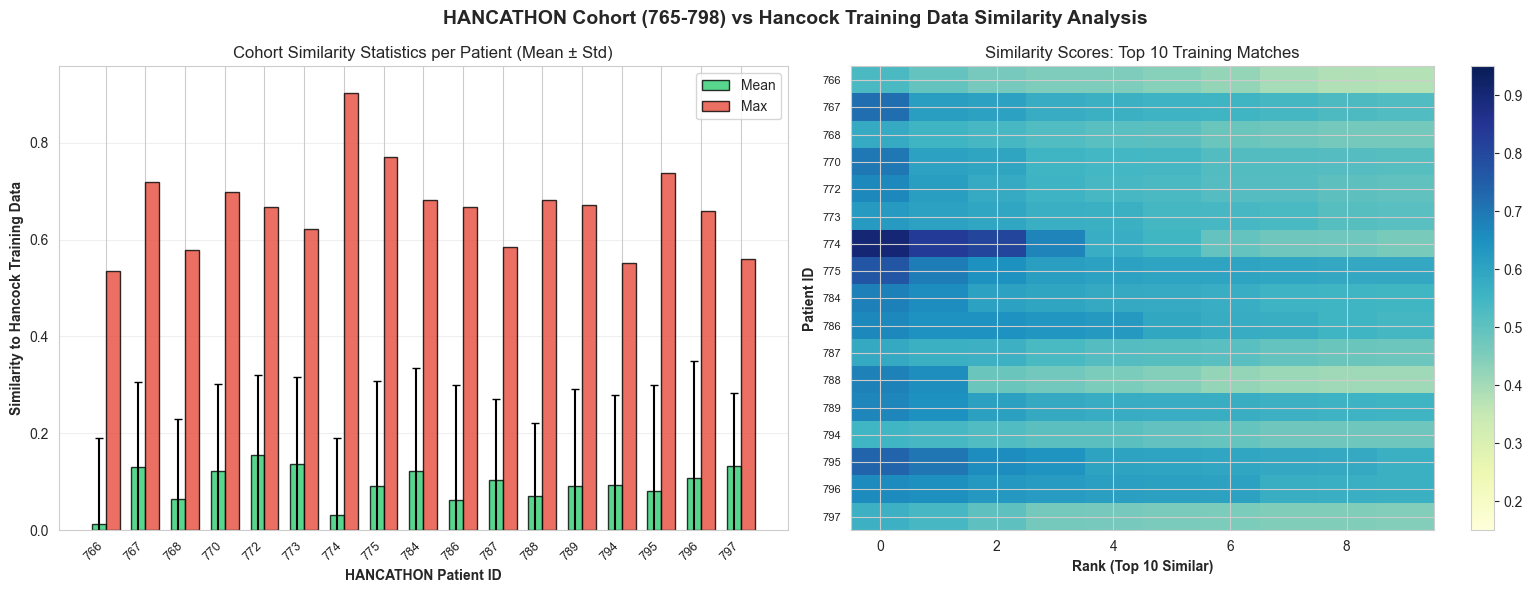

✓ HANCATHON cohort visualizations complete

HANCATHON COHORT SUMMARY (765-798)

Top 10 HANCATHON patients by maximum similarity:
Patient  Cohort_Mean  Cohort_Max
    774     0.031295    0.903120
    775     0.091153    0.771179
    795     0.080785    0.736416
    767     0.130637    0.717696
    770     0.123394    0.698372
    784     0.122112    0.682332
    788     0.071263    0.680565
    789     0.092429    0.671471
    786     0.061832    0.667856
    772     0.154885    0.666258

Maximum Similarity Statistics:
  Mean ± Std:    0.6639 ± 0.0889


In [26]:
# Load HANCATHON cohort (765-798) and compute similarity to Hancock training data
extended_patient_ids = [str(pid) for pid in range(765, 799)]
extended_patients = {}
extended_results = []
extended_similarities = {}

print("Loading HANCATHON patients (765-798)...\n")
for patient_id in extended_patient_ids:
    patient_path = f"../data/{patient_id}/raw"
    try:
        df_patient = load_and_encode_patient(patient_path, patient_id=patient_id)
        extended_patients[patient_id] = df_patient
    except Exception as e:
        # Silently skip missing patients
        print(e)
        pass

print(f"✓ Successfully loaded {len(extended_patients)} HANCATHON patients")

# Compute similarities
print("\nComputing similarities for HANCATHON cohort...\n")
print("="*90)

for patient_id, df_patient in extended_patients.items():
    # Encode patient
    X_patient = df_patient[feature_order].copy()
    X_patient_encoded = preprocessor.transform(X_patient)
    
    # Compute similarity to all training patients
    similarities = cosine_similarity(X_patient_encoded, X_train_encoded)[0]
    extended_similarities[patient_id] = similarities
    
    # Get top 5 similar training patients
    top_idx = similarities.argsort()[::-1][:5]
    top_ids = [df_train.iloc[i]['patient_id'] for i in top_idx]
    top_scores = similarities[top_idx]
    
    # Statistics
    mean_sim = np.mean(similarities)
    max_sim = np.max(similarities)
    min_sim = np.min(similarities)
    
    extended_results.append({
        'Patient': patient_id,
        'Most_Similar': int(top_ids[0]),
        'Top5_Avg_Score': top_scores.mean(),
        'Cohort_Mean': mean_sim,
        'Cohort_Max': max_sim,
        'Cohort_Min': min_sim
    })

print(f"\n✓ Computed similarities for {len(extended_results)} patients")
extended_results_df = pd.DataFrame(extended_results)

# Visualizations for extended patient set
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('HANCATHON Cohort (765-798) vs Hancock Training Data Similarity Analysis', 
             fontsize=14, fontweight='bold')

extended_patient_ids_list = list(extended_similarities.keys())

# Plot 1: Mean and max similarities per patient
ax1 = axes[0]
x = np.arange(len(extended_results_df))
width = 0.35

# Calculate std for error bars
std_per_patient_ext = [np.std(extended_similarities[pid]) for pid in extended_patient_ids_list]

ax1.bar(x - width/2, extended_results_df['Cohort_Mean'], width, label='Mean', color='#2ecc71', 
        edgecolor='black', yerr=[std_per_patient_ext, std_per_patient_ext], capsize=3, alpha=0.8)
ax1.bar(x + width/2, extended_results_df['Cohort_Max'], width, label='Max', color='#e74c3c', 
        edgecolor='black', alpha=0.8)
ax1.set_xlabel('HANCATHON Patient ID', fontweight='bold')
ax1.set_ylabel('Similarity to Hancock Training Data', fontweight='bold')
ax1.set_ylim(0,)
ax1.set_title('Cohort Similarity Statistics per Patient (Mean ± Std)')
ax1.set_xticks(x)
ax1.set_xticklabels(extended_results_df['Patient'], rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Heatmap of top similarities
ax2 = axes[1]
heatmap_data = []
for pid in extended_patient_ids_list:
    similarities = extended_similarities[pid]
    # Show top 10
    top_10_idx = similarities.argsort()[::-1][:10]
    heatmap_data.append(similarities[top_10_idx])

heatmap_array = np.array(heatmap_data)
im = ax2.imshow(heatmap_array, cmap='YlGnBu', aspect='auto', vmin=0.15, vmax=0.95)
ax2.set_yticks(range(len(extended_patient_ids_list)))
ax2.set_yticklabels(extended_results_df['Patient'].tolist(), fontsize=8)
ax2.set_xlabel('Rank (Top 10 Similar)', fontweight='bold')
ax2.set_ylabel('Patient ID', fontweight='bold')
ax2.set_title('Similarity Scores: Top 10 Training Matches')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

print("✓ HANCATHON cohort visualizations complete")

# Summary statistics
print("\n" + "="*90)
print("HANCATHON COHORT SUMMARY (765-798)")
print("="*90)
print("\nTop 10 HANCATHON patients by maximum similarity:")
top_10_extended = extended_results_df.nlargest(10, 'Cohort_Max')[['Patient', 'Cohort_Mean', 'Cohort_Max']]
print(top_10_extended.to_string(index=False))

max_similarities_ext = extended_results_df['Cohort_Max'].values
mean_max_sim_ext = np.mean(max_similarities_ext)
std_max_sim_ext = np.std(max_similarities_ext)

print(f"\nMaximum Similarity Statistics:")
print(f"  Mean ± Std:    {mean_max_sim_ext:.4f} ± {std_max_sim_ext:.4f}")
print("="*90)
